# Time Series Forecasting Refresher — BTC Hourly Returns

End-to-end workflow refresher covering classical and ML approaches to forecasting **BTC hourly log returns** at horizon H=24.

**Forecast target**: $r_t = \ln(p_t / p_{t-1})$ — log returns are (approximately) stationary and additive.

**Evaluation**: rolling 1-step-ahead RMSE, MAE, and directional accuracy on a 30-day held-out test window.

**Sections** (each major section ends with hands-on **Exercises** with hidden solutions):
1. Setup & imports
2. Data loading & sanity
3. EDA
4. Stationarity tests
5. Decomposition
6. Train/test split
7. Naive baselines
8. ETS
9. SARIMA
10. Lag-feature engineering
11. ML model + Optuna
12. Recursive multi-step
13. Feature importance
14. Model comparison
15. Diagnostics
16. Probabilistic forecast (quantile LightGBM)
17. Deployment (joblib + FastAPI)


## 1. Setup & Imports

Standard scientific Python stack plus `statsmodels` (classical), `xgboost`/`lightgbm` (ML), `optuna` (HPO), `shap` (interpretability), `joblib` (serialization).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup OK")

Setup OK


## Problem Framing

**Why log returns, not price?**
- Prices are explosively non-stationary; classical methods (ARIMA, ETS) assume stationarity.
- Log returns have constant unconditional mean (~0), bounded support in practice, and are additive: $\sum r_t = \ln(p_T/p_0)$.

**Why short horizon (1-step) eval?**
- Cumulative error compounds quickly in volatile crypto. 1-step-ahead RMSE/MAE is the cleanest, least gameable metric.
- We **also** demonstrate recursive multi-step h=1..24.

**Realistic expectations**: Hourly crypto returns are essentially a random walk. We expect RMSE differences across models to be small. A directional accuracy (dir-acc) of 49–53% is realistic; >55% would be suspicious.

## 2. Data Loading & Sanity Checks

Load the shared parquet, filter to BTC, set a `DatetimeIndex` with hourly frequency, and verify continuity.

In [2]:
DATA_PATH = "/home/zlac116/Code/learning/ml-revision/data/crypto_hourly.parquet"

raw = pd.read_parquet(DATA_PATH)
print("All symbols:", raw["symbol"].unique())
print("Raw shape:", raw.shape)

btc = (raw[raw["symbol"] == "BTC"]
       .copy()
       .sort_values("ts")
       .drop_duplicates(subset="ts"))

# UTC index, hourly frequency
btc["ts"] = pd.to_datetime(btc["ts"], utc=True)
btc = btc.set_index("ts")
btc.index = btc.index.tz_convert("UTC")

# Reindex to a strict hourly grid and forward-fill tiny gaps
full_idx = pd.date_range(btc.index.min(), btc.index.max(), freq="H", tz="UTC")
btc = btc.reindex(full_idx)
btc.index.name = "ts"

print("After reindex:", btc.shape)
print("NaNs before ffill:", btc[["close"]].isna().sum().item())
btc[["open", "high", "low", "close", "volume"]] = (
    btc[["open", "high", "low", "close", "volume"]].ffill()
)
btc["symbol"] = "BTC"
print("NaNs after ffill:", btc[["close"]].isna().sum().item())
btc.head()

All symbols: ['BNB' 'BTC' 'ETH' 'SOL']
Raw shape: (70080, 7)
After reindex: (17520, 6)
NaNs before ffill: 0
NaNs after ffill: 0


,open,high,low,close,volume,symbol
ts,,,,,,
2024-04-19 23:00:00+00:00,64012.49,64124.00,62953.90,63818.01,2825.31770,BTC
2024-04-20 00:00:00+00:00,63818.01,64263.41,63418.00,63444.51,2107.44280,BTC
2024-04-20 01:00:00+00:00,63444.51,63777.03,63090.07,63656.00,1283.85296,BTC
2024-04-20 02:00:00+00:00,63656.00,64092.29,63530.00,63834.02,882.54344,BTC
2024-04-20 03:00:00+00:00,63834.01,64040.67,63766.00,63956.00,634.11376,BTC


In [3]:
# Compute log return — our target variable
btc["log_return"] = np.log(btc["close"]).diff()
btc = btc.dropna(subset=["log_return"])
print(f"Final shape: {btc.shape}")
print(f"Period: {btc.index.min()} -> {btc.index.max()}")
print(f"Log return summary:\n{btc['log_return'].describe()}")

Final shape: (17519, 7)
Period: 2024-04-20 00:00:00+00:00 -> 2026-04-19 22:00:00+00:00
Log return summary:
count    17519.000000
mean         0.000009
std          0.005056
min         -0.050195
25%         -0.002078
50%          0.000030
75%          0.002212
max          0.049047
Name: log_return, dtype: float64


### Exercises — Data Loading

**Exercise 2.1**: Find the **longest gap** (in hours) between consecutive original timestamps in the raw BTC data (before any reindex/ffill). Report start, end, and gap length.

*Expected*: Print of `(start_ts, end_ts, gap_hours)`. For a clean dataset most gaps are 1h.

In [4]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
raw_btc = (raw[raw['symbol'] == 'BTC']
           .sort_values('ts')
           .drop_duplicates(subset='ts'))
raw_btc['ts'] = pd.to_datetime(raw_btc['ts'], utc=True)
deltas = raw_btc['ts'].diff()
i_max = deltas.idxmax()
gap_hours = deltas.loc[i_max].total_seconds() / 3600
print('Gap:', raw_btc.loc[i_max - 1, 'ts'], '->', raw_btc.loc[i_max, 'ts'],
      f'({gap_hours:.1f}h)')
```

**Explanation**: Compute consecutive timestamp deltas with `.diff()`, take `idxmax()` to find the largest gap, and print neighbours. This catches exchange outages or missing-bar issues that ffill silently hides.

</details>

**Exercise 2.2**: Verify the post-reindex BTC index is a **continuous hourly grid** with no gaps and no duplicates. Use one assert per check.

In [5]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
assert btc.index.is_monotonic_increasing, 'Index must be sorted ascending'
assert not btc.index.has_duplicates, 'No duplicate timestamps'
expected = pd.date_range(btc.index.min(), btc.index.max(), freq='H', tz='UTC')
assert len(btc) == len(expected), f'Got {len(btc)}, expected {len(expected)}'
assert (btc.index == expected).all(), 'Index must equal expected hourly grid'
print('Index continuity: OK')
```

**Explanation**: Four asserts cover monotonicity, uniqueness, length match, and value-by-value equality with the expected hourly grid. Cheap, deterministic, fail-fast.

</details>

**Exercise 2.3**: Compute the **% of original timestamps that were missing** before the reindex (i.e. gaps that were filled).

In [6]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
raw_btc = raw[raw['symbol'] == 'BTC'].drop_duplicates(subset='ts')
n_raw = len(raw_btc)
n_full = len(btc)
missing_pct = 100 * (n_full - n_raw) / n_full
print(f'Raw rows: {n_raw}, full grid: {n_full}, % filled: {missing_pct:.3f}%')
```

**Explanation**: Compare the count of unique original timestamps to the count after reindexing onto the full hourly grid. Any positive delta is gap-fill — useful for quality reporting and for deciding whether to drop affected windows.

</details>

**Exercise 2.4**: Report the dataset's **start, end, total hours, and approximate total days** in a single print.

In [7]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
n_hours = len(btc)
n_days = n_hours / 24
print(f'Start: {btc.index.min()}')
print(f'End  : {btc.index.max()}')
print(f'Hours: {n_hours} ({n_days:.1f} days)')
```

**Explanation**: Quick summary every dataset card needs. Knowing the calendar span up-front shapes downstream choices like CV fold count and seasonal period.

</details>

## 3. Exploratory Data Analysis (Time-Series Specific)

For a return series we look at: level chart, return distribution (fat tails!), rolling statistics, and **ACF/PACF of returns AND squared returns** (volatility clustering).

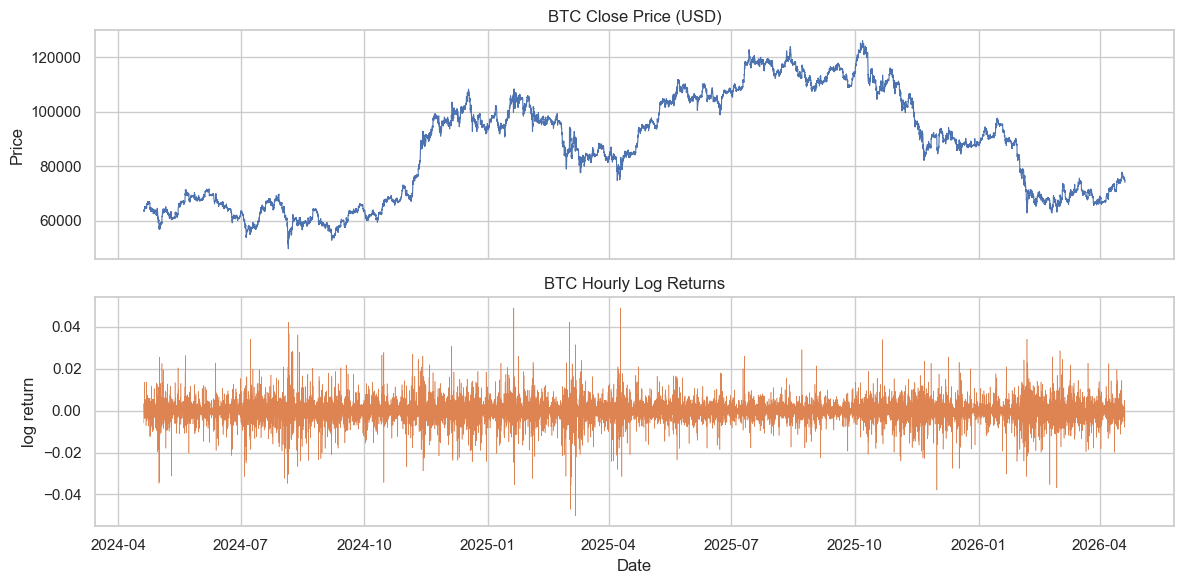

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(btc.index, btc["close"], color="C0", lw=0.8)
axes[0].set_title("BTC Close Price (USD)")
axes[0].set_ylabel("Price")
axes[1].plot(btc.index, btc["log_return"], color="C1", lw=0.4)
axes[1].set_title("BTC Hourly Log Returns")
axes[1].set_ylabel("log return")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

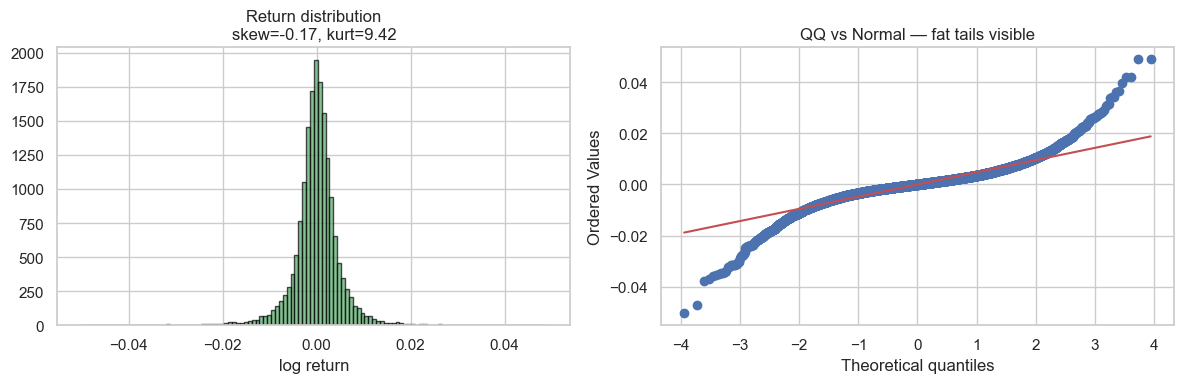

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(btc["log_return"], bins=120, color="C2", edgecolor="black", alpha=0.7)
axes[0].set_title(f"Return distribution\nskew={btc['log_return'].skew():.2f}, "
                  f"kurt={btc['log_return'].kurt():.2f}")
axes[0].set_xlabel("log return")

stats.probplot(btc["log_return"].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("QQ vs Normal — fat tails visible")
plt.tight_layout()
plt.show()

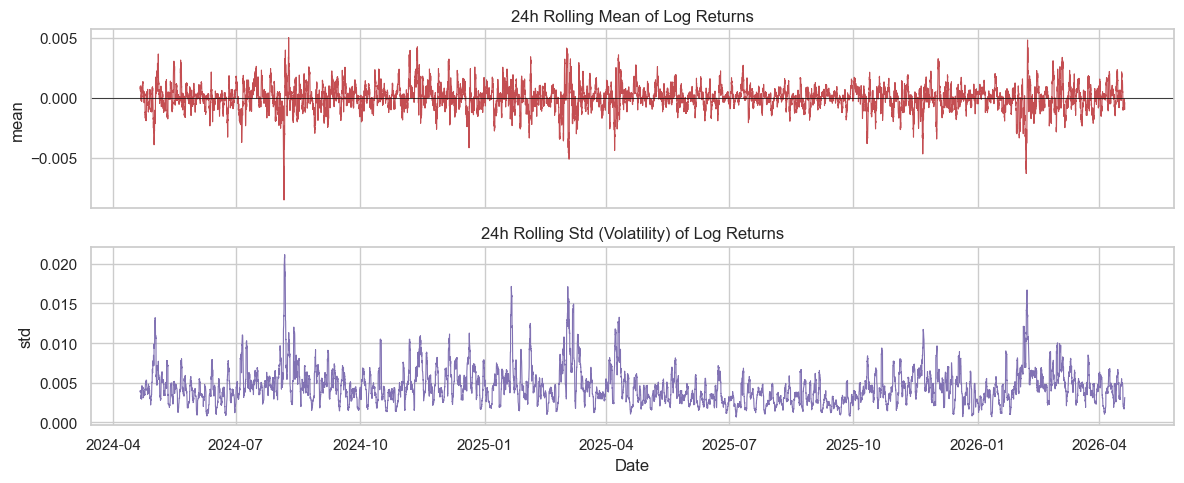

In [10]:
# Rolling mean and volatility (24h window)
rmean = btc["log_return"].rolling(24).mean()
rvol = btc["log_return"].rolling(24).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(rmean.index, rmean, color="C3", lw=0.8)
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("24h Rolling Mean of Log Returns")
axes[0].set_ylabel("mean")

axes[1].plot(rvol.index, rvol, color="C4", lw=0.8)
axes[1].set_title("24h Rolling Std (Volatility) of Log Returns")
axes[1].set_ylabel("std")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

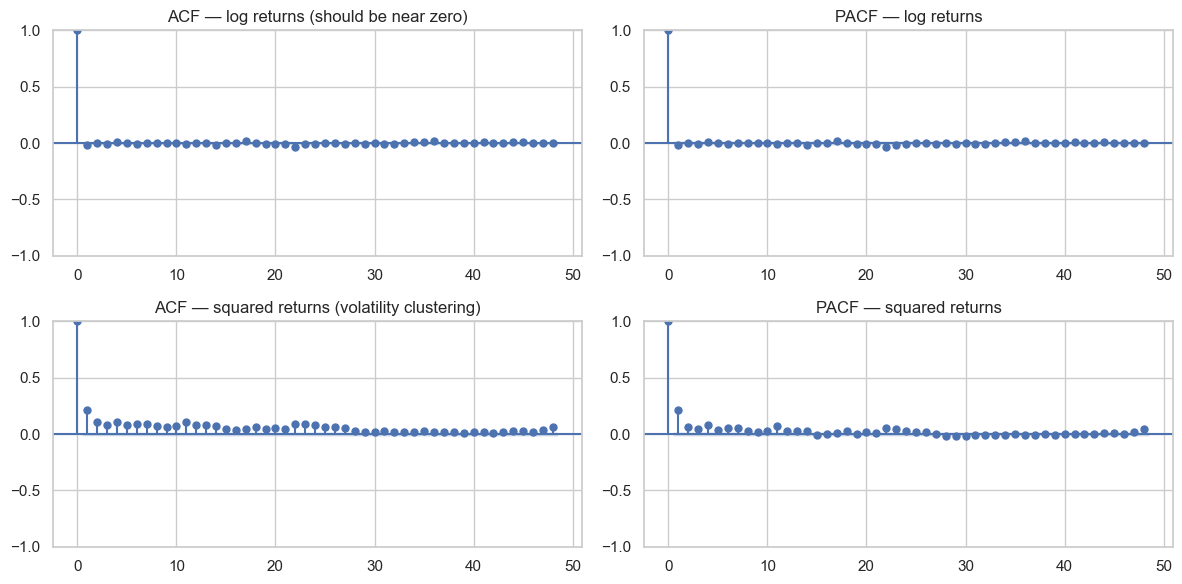

In [11]:
# ACF / PACF of returns and squared returns
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
plot_acf(btc["log_return"].dropna(), lags=48, ax=axes[0, 0])
axes[0, 0].set_title("ACF — log returns (should be near zero)")
plot_pacf(btc["log_return"].dropna(), lags=48, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF — log returns")

plot_acf(btc["log_return"].dropna() ** 2, lags=48, ax=axes[1, 0])
axes[1, 0].set_title("ACF — squared returns (volatility clustering)")
plot_pacf(btc["log_return"].dropna() ** 2, lags=48, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF — squared returns")
plt.tight_layout()
plt.show()

### Exercises — EDA

**Exercise 3.1**: Plot the **7-day rolling volatility** (std of log returns over a 24*7 window) for the entire history.

In [12]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
vol_7d = btc['log_return'].rolling(24 * 7).std()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(vol_7d.index, vol_7d, color='C5', lw=0.9)
ax.set_title('BTC 7-Day Rolling Volatility (hourly log returns)')
ax.set_xlabel('Date')
ax.set_ylabel('std')
plt.tight_layout(); plt.show()
```

**Explanation**: A 168-hour rolling std smooths out intraday noise and reveals macro vol regimes (calm vs stressed). Identifying these regimes matters for vol-targeting strategies and for robust loss design.

</details>

**Exercise 3.2**: Compute the **Hurst exponent** of log returns using a simple R/S estimator on 5 chunks. H ≈ 0.5 = random walk; H < 0.5 = mean reverting; H > 0.5 = trending.

In [13]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
def hurst_rs(x, n_chunks=5):
    x = np.asarray(x)
    chunk = len(x) // n_chunks
    rs_vals = []
    for i in range(n_chunks):
        seg = x[i * chunk:(i + 1) * chunk]
        z = seg - seg.mean()
        r = z.cumsum().max() - z.cumsum().min()
        s = seg.std(ddof=1)
        if s > 0:
            rs_vals.append(r / s)
    log_n = np.log(chunk)
    log_rs = np.log(np.mean(rs_vals))
    return log_rs / log_n
h = hurst_rs(btc['log_return'].dropna().values)
print(f'Hurst (R/S, 5 chunks): {h:.3f}')
```

**Explanation**: Single-scale R/S is the simplest possible estimator. For BTC hourly returns expect H near 0.5 (random walk). True Hurst estimation needs multi-scale R/S or DFA, but this is enough for a smell test.

</details>

**Exercise 3.3**: Box plot of log returns by **hour-of-day** (0..23). Is there a visible intraday seasonality?

In [14]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
tmp = btc.copy()
tmp['hour'] = tmp.index.hour
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=tmp, x='hour', y='log_return', ax=ax,
            showfliers=False, color='C6')
ax.set_title('BTC Log Returns by Hour of Day (UTC)')
ax.axhline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()
```

**Explanation**: Group by hour-of-day and box-plot. Crypto trades 24/7, so intraday seasonality is much weaker than equities. Any visible pattern is more likely a microstructure artefact (UTC funding times, US open) than tradeable alpha.

</details>

**Exercise 3.4**: Compute the **autocorrelation manually** at lags 1, 24, and 168 using `np.corrcoef` (not statsmodels). Compare to statsmodels' `acf`.

In [15]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
from statsmodels.tsa.stattools import acf as sm_acf
r = btc['log_return'].dropna().values
for k in [1, 24, 168]:
    rho_manual = np.corrcoef(r[:-k], r[k:])[0, 1]
    rho_sm = sm_acf(r, nlags=k, fft=False)[k]
    print(f'Lag {k:3d}: manual={rho_manual:+.4f}  statsmodels={rho_sm:+.4f}')
```

**Explanation**: Manual lag-k autocorrelation is just `corrcoef(x[:-k], x[k:])`. statsmodels' `acf` divides by N (biased) instead of N-k, so values can differ slightly at long lags. Both should agree at low lags.

</details>

## 4. Stationarity Tests

- **ADF** (Augmented Dickey-Fuller): null = unit root (non-stationary). Low p-value → stationary.
- **KPSS**: null = stationary. High p-value → stationary. Cross-check ADF.

Expected: price is non-stationary, log returns are stationary.

In [16]:
def adf_report(s, name):
    s = pd.Series(s).dropna()
    stat, p, lags, n, crit, _ = adfuller(s, autolag="AIC")
    print(f"[ADF] {name:20s}  stat={stat:+.3f}  p={p:.4g}  "
          f"lags={lags}  n={n}  -> {'STATIONARY' if p < 0.05 else 'non-stationary'}")

def kpss_report(s, name):
    s = pd.Series(s).dropna()
    stat, p, lags, crit = kpss(s, regression="c", nlags="auto")
    print(f"[KPSS] {name:20s}  stat={stat:+.3f}  p={p:.4g}  "
          f"lags={lags}  -> {'STATIONARY' if p > 0.05 else 'non-stationary'}")

adf_report(btc["close"], "close (price)")
adf_report(btc["log_return"], "log_return")
kpss_report(btc["close"], "close (price)")
kpss_report(btc["log_return"], "log_return")

[ADF] close (price)         stat=-1.494  p=0.5365  lags=22  n=17496  -> non-stationary


[ADF] log_return            stat=-29.452  p=0  lags=22  n=17496  -> STATIONARY
[KPSS] close (price)         stat=+8.206  p=0.01  lags=77  -> non-stationary
[KPSS] log_return            stat=+0.201  p=0.1  lags=6  -> STATIONARY


/tmp/ipykernel_709517/522047728.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, lags, crit = kpss(s, regression="c", nlags="auto")
/tmp/ipykernel_709517/522047728.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, crit = kpss(s, regression="c", nlags="auto")


### Exercises — Stationarity

**Exercise 4.1**: Run ADF on a **30-day rolling window** of log returns. Plot the p-value over time. Long stretches above 0.05 suggest non-stationary regimes.

In [17]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
win = 24 * 30  # 30 days of hours
step = 24      # advance one day at a time
r = btc['log_return'].dropna()
pvals, idxs = [], []
for end in range(win, len(r), step):
    seg = r.iloc[end - win:end]
    try:
        p = adfuller(seg, autolag='AIC')[1]
    except Exception:
        p = np.nan
    pvals.append(p); idxs.append(r.index[end - 1])
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(idxs, pvals, color='C7')
ax.axhline(0.05, color='red', ls='--', label='p=0.05')
ax.set_title('30-day Rolling ADF p-value (log returns)')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: Step the ADF over a sliding 720-hour window and stride by 24h to keep it cheap. Spikes above 0.05 flag periods when the series briefly looks non-stationary — usually transient and not a problem for return-based modelling.

</details>

**Exercise 4.2**: Run KPSS on price and log returns and **reconcile** with ADF. State the four ADF/KPSS combinations and what they imply.

In [18]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
kpss_report(btc['close'], 'close')
kpss_report(btc['log_return'], 'log_return')
print()
print('ADF reject + KPSS not-reject => stationary')
print('ADF not-reject + KPSS reject => non-stationary')
print('Both reject              => trend-stationary or fractionally integrated')
print('Neither rejects          => low power; need more data')
```

**Explanation**: ADF and KPSS swap the null and alternative, so they can disagree. The four-way decision matrix is standard practice — agreement gives confidence; disagreement points at trend-stationarity, structural breaks, or insufficient data.

</details>

**Exercise 4.3**: First-difference price (`close.diff()`) and re-run ADF. Compare its p-value to ADF on `log_return`.

In [19]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
diff_close = btc['close'].diff()
adf_report(diff_close, 'diff(close)')
adf_report(btc['log_return'], 'log_return')
```

**Explanation**: Both transforms remove the unit root, but log returns are scale-invariant — comparable across asset price levels — while raw differences are not. Use log returns for cross-asset modelling.

</details>

**Exercise 4.4**: Run ADF on `log(squared returns + eps)` and interpret. (This proxies log volatility — is it stationary?)

In [20]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
eps = 1e-12
log_sq = np.log(btc['log_return'] ** 2 + eps)
adf_report(log_sq, 'log(returns^2)')
```

**Explanation**: Log squared returns is a noisy proxy for log realised variance. ADF typically rejects (stationary) but the series has long memory in practice — formal tests (Hurst, GPH) often suggest fractional integration. Either way, GARCH-style modelling is justified.

</details>

## 5. Seasonal Decomposition

Decompose price (or returns) into trend + seasonal + residual.

**Caveats**:
- Crypto trades 24/7 — seasonality is weak.
- `seasonal_decompose` uses centred moving averages; STL is more robust.
- We pick **additive** for log returns (the natural scale).

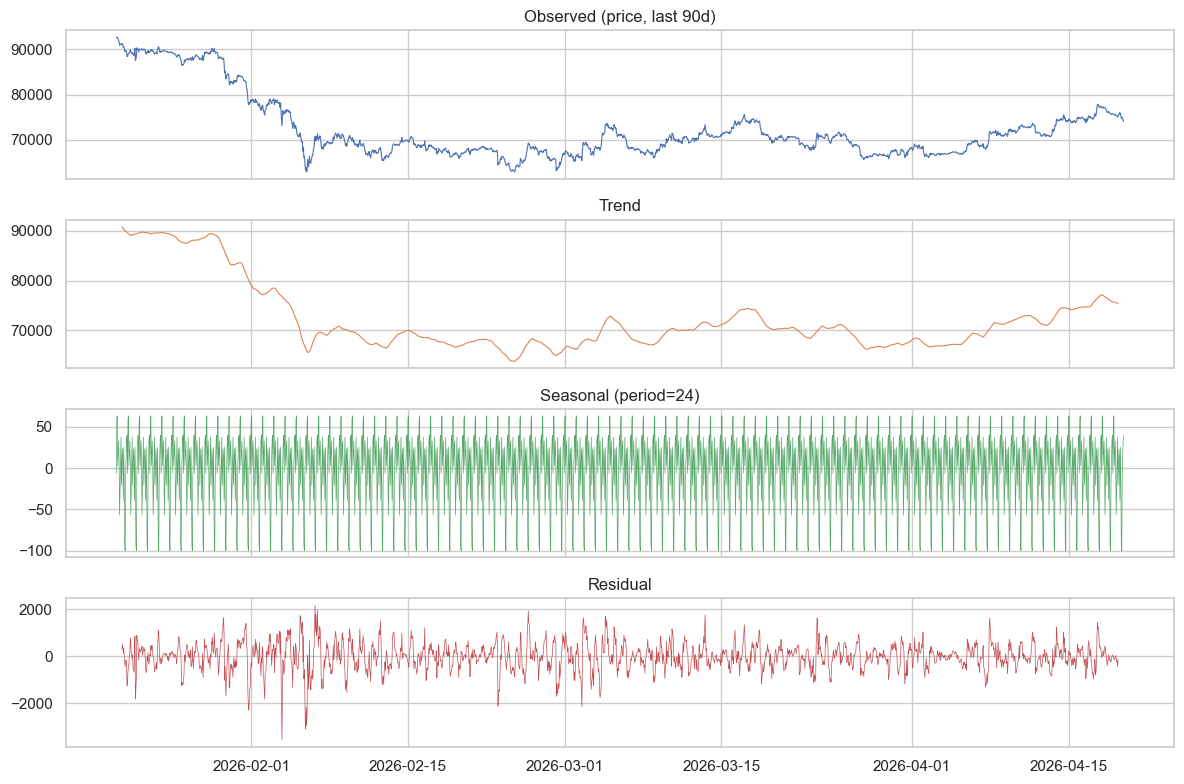

In [21]:
# Use last 90 days of price (additive decomposition with daily period=24)
window = btc.iloc[-24 * 90:]
decomp = seasonal_decompose(window["close"], model="additive", period=24)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(window.index, decomp.observed, lw=0.8); axes[0].set_title("Observed (price, last 90d)")
axes[1].plot(window.index, decomp.trend, lw=0.8, color="C1"); axes[1].set_title("Trend")
axes[2].plot(window.index, decomp.seasonal, lw=0.5, color="C2"); axes[2].set_title("Seasonal (period=24)")
axes[3].plot(window.index, decomp.resid, lw=0.5, color="C3"); axes[3].set_title("Residual")
plt.tight_layout(); plt.show()

### Exercises — Decomposition

**Exercise 5.1**: Run **STL decomposition** with period=24 on the same 90-day window. Plot trend/seasonal/residual.

In [22]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
stl = STL(window['close'], period=24, robust=True).fit()
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
axes[0].plot(stl.trend, lw=0.8); axes[0].set_title('STL Trend')
axes[1].plot(stl.seasonal, lw=0.5, color='C2'); axes[1].set_title('STL Seasonal (24h)')
axes[2].plot(stl.resid, lw=0.5, color='C3'); axes[2].set_title('STL Residual')
plt.tight_layout(); plt.show()
```

**Explanation**: STL (Seasonal-Trend-LOESS) is more robust to outliers than `seasonal_decompose`. The `robust=True` flag downweights large residuals — important for crypto.

</details>

**Exercise 5.2**: Decompose **returns** (not price) with period=24 and interpret the seasonal magnitude vs the residual magnitude.

In [23]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
win_r = btc['log_return'].iloc[-24 * 90:]
dec_r = seasonal_decompose(win_r, model='additive', period=24)
print(f'Seasonal std: {dec_r.seasonal.std():.6f}')
print(f'Residual std: {dec_r.resid.std():.6f}')
print(f'Seasonal / total: {dec_r.seasonal.std() / win_r.std():.3%}')
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(dec_r.seasonal[-24 * 7:], lw=0.8)
ax.set_title('Last week of seasonal component (returns)')
plt.tight_layout(); plt.show()
```

**Explanation**: Comparing seasonal std to residual std quantifies how much variance the diurnal cycle actually explains. For BTC returns this fraction is tiny (<5%) — seasonality is essentially noise at the hourly scale.

</details>

**Exercise 5.3**: Plot the **last 7 days** of the seasonal component overlaid on the raw price (twin axis).

In [24]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
last7 = decomp.seasonal[-24 * 7:]
raw7 = window['close'][-24 * 7:]
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(raw7.index, raw7, color='C0', lw=0.9, label='Price')
ax1.set_ylabel('Price'); ax1.set_xlabel('Date')
ax2 = ax1.twinx()
ax2.plot(last7.index, last7, color='C2', lw=0.8, label='Seasonal')
ax2.set_ylabel('Seasonal')
ax1.set_title('Price vs 24h-seasonal component (last 7 days)')
plt.tight_layout(); plt.show()
```

**Explanation**: Overlay shows how visually-tiny the seasonal signal is relative to price moves. A useful sanity check that you're not chasing a periodic ghost.

</details>

**Exercise 5.4**: Compute a **strength-of-seasonality** metric: $F_s = \max(0, 1 - \mathrm{Var}(R)/\mathrm{Var}(S+R))$ where S, R are seasonal and residual components. Range [0, 1].

In [25]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
S = decomp.seasonal.dropna()
R = decomp.resid.dropna()
common = S.index.intersection(R.index)
Fs = max(0.0, 1.0 - R.loc[common].var() / (S.loc[common] + R.loc[common]).var())
print(f'Strength of seasonality F_s = {Fs:.3f}')
```

**Explanation**: Hyndman's F_s metric (FPP3, ch.6.7). Values near 1 indicate strong seasonality; values near 0 mean the seasonal component adds essentially no explanatory power. Crypto hourly price hovers near zero.

</details>

## 6. Chronological Train/Test Split

**Last 30 days** = test, prior = train. Never shuffle time series — it leaks the future.

In [26]:
TEST_DAYS = 30
TEST_HOURS = 24 * TEST_DAYS

split_idx = len(btc) - TEST_HOURS
train = btc.iloc[:split_idx].copy()
test = btc.iloc[split_idx:].copy()
print(f"Train: {len(train)} hours ({train.index.min()} -> {train.index.max()})")
print(f"Test : {len(test)} hours ({test.index.min()} -> {test.index.max()})")
assert train.index.max() < test.index.min(), "Train and test must not overlap"


Train: 16799 hours (2024-04-20 00:00:00+00:00 -> 2026-03-20 22:00:00+00:00)
Test : 720 hours (2026-03-20 23:00:00+00:00 -> 2026-04-19 22:00:00+00:00)


### Exercises — Split

**Exercise 6.1**: Implement a **walk-forward CV** with 5 expanding-window folds on `train` (using `sklearn.model_selection.TimeSeriesSplit`). Print fold sizes.

In [27]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
tscv = TimeSeriesSplit(n_splits=5)
for i, (tr_idx, va_idx) in enumerate(tscv.split(train)):
    print(f'Fold {i}: train={len(tr_idx):>6d}  val={len(va_idx):>5d}  '
          f'val_start={train.index[va_idx[0]]}')
```

**Explanation**: `TimeSeriesSplit` produces expanding-window folds where each train set is a prefix of the data. This mirrors how the model is actually used in production — fit on the past, score on the future.

</details>

**Exercise 6.2**: Compare **mean and std** of `log_return` between train and test. Big shifts hint at distribution drift.

In [28]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
summary = pd.DataFrame({
    'train': train['log_return'].agg(['mean', 'std', 'min', 'max']),
    'test':  test['log_return'].agg(['mean', 'std', 'min', 'max']),
})
print(summary)
```

**Explanation**: Compare moments to spot regime changes. Big mean/std shifts mean your IS metrics overstate OOS performance — common in crypto where vol regimes flip quickly.

</details>

**Exercise 6.3**: **Verify no overlap**: assert `train.index` and `test.index` are disjoint, and that train ends exactly one hour before test starts.

In [29]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
overlap = train.index.intersection(test.index)
assert len(overlap) == 0, f'Overlap of {len(overlap)} timestamps!'
gap = test.index.min() - train.index.max()
print(f'Train ends: {train.index.max()}')
print(f'Test starts: {test.index.min()}')
print(f'Gap: {gap}  (expect 1 hour)')
assert gap == pd.Timedelta('1h'), 'Train/test should be exactly 1h apart'
```

**Explanation**: Three asserts: empty intersection, exact 1-hour gap. Catching a 1-row off-by-one here saves hours of confused debugging later.

</details>

**Exercise 6.4**: Show with a tiny code snippet **why** a shuffled split breaks the problem (compute test-set mean if you randomly sample test indices from anywhere in the series; show how naive baselines fitted on train look).

In [30]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
rng = np.random.default_rng(0)
shuf_test_idx = rng.choice(len(btc), size=TEST_HOURS, replace=False)
shuf_train_idx = np.setdiff1d(np.arange(len(btc)), shuf_test_idx)
print('Chronological test mean :', test['log_return'].mean())
print('Shuffled     test mean  :', btc['log_return'].iloc[shuf_test_idx].mean())
print('Shuffled train contains hours AFTER shuffled test? ',
      btc.index[shuf_train_idx].max() > btc.index[shuf_test_idx].min())
print('=> shuffled split lets the model peek at the future via lag features')
```

**Explanation**: Shuffled splits put future bars in train and past bars in test — every lag feature becomes a leak. The print statement makes the temporal contamination obvious.

</details>

## 7. Naive Baselines

For 1-step-ahead return forecasting:
- **Zero-return** (efficient market hypothesis): $\hat r_t = 0$.
- **Random-walk on price**: $\hat p_t = p_{t-1}$ → equivalent to predicting $\hat r_t = 0$.
- **Seasonal naive (daily)**: $\hat r_t = r_{t-24}$.
- **Seasonal naive (weekly)**: $\hat r_t = r_{t-168}$.

In [31]:
def metrics(y_true, y_pred, name):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    # directional accuracy: ignore exact zeros
    nz = (yt != 0)
    dir_acc = (np.sign(yp[nz]) == np.sign(yt[nz])).mean()
    return {"model": name, "rmse": rmse, "mae": mae, "dir_acc": dir_acc, "n": int(mask.sum())}

y_test = test["log_return"].values

# Naive: predict zero
pred_zero = np.zeros_like(y_test)

# Seasonal naive: predict r_{t-24} (daily)
last_train_returns = btc["log_return"].copy()
pred_sn24 = last_train_returns.shift(24).loc[test.index].values

# Seasonal naive: predict r_{t-168} (weekly)
pred_sn168 = last_train_returns.shift(168).loc[test.index].values

baseline_results = [
    metrics(y_test, pred_zero, "naive_zero"),
    metrics(y_test, pred_sn24, "seasonal_naive_24h"),
    metrics(y_test, pred_sn168, "seasonal_naive_168h"),
]
pd.DataFrame(baseline_results).round(6)

,model,rmse,mae,dir_acc,n
0,naive_zero,0.004392,0.003009,0.000000,720
1,seasonal_naive_24h,0.006329,0.004423,0.516667,720
2,seasonal_naive_168h,0.006243,0.004377,0.506944,720


### Exercises — Naive Baselines

**Exercise 7.1**: Implement seasonal naive at period=168 (weekly) **manually** (no shift): for each test timestamp t, look up `log_return` 168 hours before t.

In [32]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
preds = []
for ts in test.index:
    src = ts - pd.Timedelta(hours=168)
    preds.append(btc['log_return'].get(src, np.nan))
preds = np.array(preds)
print(metrics(y_test, preds, 'manual_sn168'))
```

**Explanation**: Manual lookup verifies the `shift(168)` approach gives identical results. Useful when you want custom calendar-aware lookups (e.g. skip weekends for traditional markets).

</details>

**Exercise 7.2**: **Blend** naive (predict 0) with seasonal naive 24h, 50/50. Compare metrics.

In [33]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
blend = 0.5 * pred_zero + 0.5 * np.nan_to_num(pred_sn24, nan=0.0)
print(metrics(y_test, blend, 'blend_zero_sn24'))
```

**Explanation**: Blending shrinks the seasonal-naive prediction toward zero. For a near-random-walk series this typically improves RMSE simply because shrinking variance reduces MSE.

</details>

**Exercise 7.3**: Compute **directional accuracy manually** for `pred_sn24` without using the helper: count of `sign(pred) == sign(actual)` where actual != 0, divided by N.

In [34]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
p = pred_sn24
y = y_test
mask = ~np.isnan(p) & (y != 0)
hit = (np.sign(p[mask]) == np.sign(y[mask])).sum()
n = mask.sum()
print(f'manual dir_acc = {hit / n:.4f}  ({hit}/{n})')
```

**Explanation**: Direct check that the helper isn't doing anything sneaky. Always sanity-check key metrics by hand at least once.

</details>

**Exercise 7.4**: Compute a **bootstrap 95% CI** on the naive-zero RMSE (1000 resamples of the test residuals).

In [35]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
rng = np.random.default_rng(0)
resid = y_test - pred_zero
boot_rmse = []
for _ in range(1000):
    idx = rng.integers(0, len(resid), size=len(resid))
    boot_rmse.append(np.sqrt(np.mean(resid[idx] ** 2)))
lo, hi = np.percentile(boot_rmse, [2.5, 97.5])
print(f'naive-zero RMSE 95% CI: [{lo:.6f}, {hi:.6f}]')
```

**Explanation**: A bootstrap CI tells you the noise in your point estimate. If a competing model's RMSE falls inside this CI, the improvement isn't statistically meaningful.

</details>

## 8. Classical: ETS (Exponential Smoothing)

We fit **simple exponential smoothing (SES) on log returns** — appropriate when there is no clear trend or seasonality (which is the case for hourly returns).

For each test step, we re-fit SES on the expanding training window and predict 1 step. To keep this fast we update by **appending the new observation to the model** rather than refitting from scratch.

In [36]:
# Walk-forward 1-step-ahead with SES on log returns.
# Trick: refit only every K steps to keep runtime manageable.
REFIT_EVERY = 24  # refit once per day

train_ret = train["log_return"].copy()
preds_ets = []
fitted_model = None

t0 = time.time()
for i, ts in enumerate(test.index):
    history = pd.concat([train_ret, test["log_return"].iloc[:i]])
    if i % REFIT_EVERY == 0 or fitted_model is None:
        fitted_model = ExponentialSmoothing(
            history.values, trend=None, seasonal=None, initialization_method="estimated"
        ).fit(optimized=True)
    yhat = fitted_model.forecast(1)[0]
    preds_ets.append(yhat)
preds_ets = np.array(preds_ets)
print(f"ETS walk-forward took {time.time() - t0:.1f}s")
print(metrics(y_test, preds_ets, "ets_ses"))


ETS walk-forward took 41.0s
{'model': 'ets_ses', 'rmse': np.float64(0.004391574583893722), 'mae': 0.003008985780381208, 'dir_acc': np.float64(0.5027777777777778), 'n': 720}


### Exercises — ETS

**Exercise 8.1**: Fit a **Holt-Winters** model with `seasonal_periods=24` on the **last 14 days of price** (additive), forecast 24 hours ahead, plot.

In [37]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
hist = btc['close'].iloc[-24 * 14:-24]
actual_next = btc['close'].iloc[-24:]
hw = ExponentialSmoothing(hist, trend='add', seasonal='add',
                          seasonal_periods=24,
                          initialization_method='estimated').fit()
fc = hw.forecast(24)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hist.index[-24 * 3:], hist.iloc[-24 * 3:], label='history')
ax.plot(actual_next.index, actual_next.values, label='actual')
ax.plot(actual_next.index, fc.values, label='HW forecast', ls='--')
ax.set_title('Holt-Winters 24h forecast on price')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: Holt-Winters adds a seasonal component to ETS. On price (non-stationary) it tends to over-fit short trends and seasonal cycles in crypto, but the visualisation makes the dangers clear.

</details>

**Exercise 8.2**: Fit ETS with **damped trend** on log returns and compare AIC against the SES model.

In [38]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
m1 = ExponentialSmoothing(train_ret.values, trend=None,
                          initialization_method='estimated').fit()
m2 = ExponentialSmoothing(train_ret.values, trend='add', damped_trend=True,
                          initialization_method='estimated').fit()
print(f'SES AIC          : {m1.aic:.2f}')
print(f'Damped trend AIC : {m2.aic:.2f}')
```

**Explanation**: Damped trend (Gardner-McKenzie) shrinks the slope toward zero with phi<1. For pure-noise return series, trend models tend to overfit and have higher AIC. Lower AIC is better.

</details>

**Exercise 8.3**: Show the **learned smoothing parameter alpha** for the last fitted SES model.

In [39]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
alpha = fitted_model.params['smoothing_level']
print(f'Learned alpha: {alpha:.4f}')
print('alpha ~ 0   => heavy smoothing (forecast = long mean)')
print('alpha ~ 1   => no smoothing (forecast = last observation)')
```

**Explanation**: alpha is fit by maximum likelihood. For near-zero-mean noise the optimiser usually drives alpha toward 0, meaning SES reduces to forecasting the long-run mean (~0).

</details>

**Exercise 8.4**: Plot **in-sample fitted vs actual** for the SES on the **last 200 hours** of train.

In [40]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
model = ExponentialSmoothing(train_ret.values, trend=None,
                             initialization_method='estimated').fit()
fitted = model.fittedvalues
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_ret.index[-200:], train_ret.values[-200:], label='actual', lw=0.7)
ax.plot(train_ret.index[-200:], fitted[-200:], label='fitted', lw=0.7)
ax.set_title('SES — in-sample fitted vs actual (last 200 hours)')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: On near-noise series the SES fitted line collapses to a near-flat track close to zero. This visually confirms why ETS rarely beats naive on hourly crypto returns.

</details>

## 9. Classical: SARIMA (small grid)

We fit SARIMA on log returns (already differenced once via the log-return transform, so d=0). Tiny grid:
- $(p,d,q) \in \{0,1,2\} \times \{0\} \times \{0,1,2\}$
- $(P,D,Q,s) = (P,0,Q,24)$ with $P, Q \in \{0,1\}$

Pick best by AIC on a **subsample** of train (last 6000 hours) — full history would be slow.

**Walk-forward**: refit every 24h to keep it CPU-friendly.

In [41]:
TRAIN_SUBSAMPLE = 6000  # last N hours of train for grid search
sub = train["log_return"].iloc[-TRAIN_SUBSAMPLE:]

best_aic = np.inf
best_order = None
best_seasonal = None

t0 = time.time()
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    m = SARIMAX(sub, order=(p, 0, q), seasonal_order=(P, 0, Q, 24),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False, maxiter=50)
                    if m.aic < best_aic:
                        best_aic = m.aic
                        best_order = (p, 0, q)
                        best_seasonal = (P, 0, Q, 24)
                except Exception:
                    continue
print(f"SARIMA grid took {time.time() - t0:.1f}s")
print(f"Best SARIMA{best_order}x{best_seasonal}  AIC={best_aic:.2f}")

/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA grid took 194.7s
Best SARIMA(0, 0, 0)x(0, 0, 0, 24)  AIC=-47261.48


In [42]:
# Walk-forward 1-step-ahead with the chosen order
t0 = time.time()
preds_sarima = []
fitted_sarima = None
REFIT_EVERY_S = 48  # refit every 2 days

for i, ts in enumerate(test.index):
    history = pd.concat([train["log_return"], test["log_return"].iloc[:i]])
    if i % REFIT_EVERY_S == 0 or fitted_sarima is None:
        # use only last 4000 hours for refit speed
        hist_used = history.iloc[-4000:]
        fitted_sarima = SARIMAX(hist_used.values, order=best_order,
                                seasonal_order=best_seasonal,
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False, maxiter=50)
    yhat = fitted_sarima.forecast(1)[0]
    preds_sarima.append(yhat)

preds_sarima = np.array(preds_sarima)
print(f"SARIMA walk-forward took {time.time() - t0:.1f}s")
print(metrics(y_test, preds_sarima, f'sarima{best_order}x{best_seasonal}'))

/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA walk-forward took 5.9s
{'model': 'sarima(0, 0, 0)x(0, 0, 0, 24)', 'rmse': np.float64(0.004391538810215462), 'mae': 0.0030089344095076192, 'dir_acc': np.float64(0.0), 'n': 720}


/home/zlac116/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Exercises — SARIMA

**Exercise 9.1**: Plot the **residual ACF** of the best SARIMA fit and run a **Ljung-Box test** at lag 24. Are residuals white noise?

In [43]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
resid = pd.Series(fitted_sarima.resid).dropna()
fig, ax = plt.subplots(figsize=(10, 3))
plot_acf(resid, lags=48, ax=ax)
ax.set_title('SARIMA residual ACF')
plt.tight_layout(); plt.show()
lb = acorr_ljungbox(resid, lags=[24], return_df=True)
print(lb)
print('p > 0.05 => residuals indistinguishable from white noise')
```

**Explanation**: Residual ACF should be flat. Ljung-Box at lag 24 tests autocorrelation up to 1 day — large p-value means no remaining structure for the model to exploit.

</details>

**Exercise 9.2**: Re-run the grid and print the **top 3 by AIC**. Compare ΔAIC.

In [44]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
results = []
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    m = SARIMAX(sub, order=(p, 0, q), seasonal_order=(P, 0, Q, 24),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False, maxiter=50)
                    results.append({'order': (p, 0, q),
                                    'seasonal': (P, 0, Q, 24), 'aic': m.aic})
                except Exception:
                    pass
df = pd.DataFrame(results).sort_values('aic').head(3).reset_index(drop=True)
df['delta_aic'] = df['aic'] - df['aic'].iloc[0]
print(df)
```

**Explanation**: Reporting the top-K is honest: if delta-AIC < 2 the models are essentially indistinguishable. Always treat AIC ranking as ordinal, not absolute.

</details>

**Exercise 9.3**: Implement an **AR(1) by hand** on `train_ret`: $r_t = c + \phi r_{t-1} + \epsilon_t$ via OLS. Verify $\phi$ matches statsmodels' SARIMAX(1,0,0).

In [45]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
r = train_ret.dropna().values
y = r[1:]
X = np.column_stack([np.ones_like(r[:-1]), r[:-1]])
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
c_hat, phi_hat = beta
print(f'manual c={c_hat:+.6f}  phi={phi_hat:+.6f}')
sm = SARIMAX(r, order=(1, 0, 0), trend='c').fit(disp=False)
print(f'sm     c={sm.params[0]:+.6f}  phi={sm.params[1]:+.6f}')
```

**Explanation**: AR(1) is just OLS of r_t on r_{t-1}. Both methods should agree to 4+ decimals — useful as a sanity check that you understand what statsmodels is doing under the hood.

</details>

**Exercise 9.4**: Plot **in-sample fitted vs actual residuals** of the last SARIMA fit on the last 200 observations.

In [46]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
fitted_vals = fitted_sarima.fittedvalues[-200:]
actual_vals = pd.Series(fitted_sarima.data.endog).iloc[-200:].values
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actual_vals, label='actual', lw=0.7)
ax.plot(fitted_vals, label='SARIMA fitted', lw=0.7)
ax.set_title('SARIMA in-sample fit (last 200 obs)')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: If fitted essentially overlays actual the model is overfit. For near-noise data fitted should hug zero — anything else suggests parameter capture of noise.

</details>

## 10. Lag-Feature Engineering for ML

We turn the time series into a tabular regression problem. Features at time $t$ use **only data observed up to $t$** (no leakage):
- Lags of `log_return`: 1, 2, 3, 6, 12, 24, 48, 168
- Rolling mean and std of `log_return` over 24h, 168h
- Rolling vol of squared returns
- Calendar: hour-of-day, day-of-week (sin/cos encoded)
- Volume z-score (rolling 168h)

In [47]:
LAGS = [1, 2, 3, 6, 12, 24, 48, 168]
ROLL_WINDOWS = [24, 168]

def make_features(df):
    out = pd.DataFrame(index=df.index)
    r = df["log_return"]
    for l in LAGS:
        out[f"lag_{l}"] = r.shift(l)
    for w in ROLL_WINDOWS:
        out[f"rmean_{w}"] = r.shift(1).rolling(w).mean()
        out[f"rstd_{w}"]  = r.shift(1).rolling(w).std()
        out[f"rvol2_{w}"] = (r.shift(1) ** 2).rolling(w).mean()
    # Calendar
    h = df.index.hour
    d = df.index.dayofweek
    out["sin_h"] = np.sin(2 * np.pi * h / 24)
    out["cos_h"] = np.cos(2 * np.pi * h / 24)
    out["sin_d"] = np.sin(2 * np.pi * d / 7)
    out["cos_d"] = np.cos(2 * np.pi * d / 7)
    # Volume z-score
    v = df["volume"]
    vmean = v.shift(1).rolling(168).mean()
    vstd  = v.shift(1).rolling(168).std()
    out["vol_z168"] = (v.shift(1) - vmean) / vstd
    return out

X_full = make_features(btc)
y_full = btc["log_return"]

# Drop initial NaN rows (longest lookback = 168)
valid = X_full.dropna().index
X_full = X_full.loc[valid]
y_full = y_full.loc[valid]
print("Feature matrix:", X_full.shape)
X_full.head()

Feature matrix: (17351, 19)


,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_168,rmean_24,rstd_24,rvol2_24,rmean_168,rstd_168,rvol2_168,sin_h,cos_h,sin_d,cos_d,vol_z168
ts,,,,,,,,,,,,,,,,,,,
2024-04-27 00:00:00+00:00,-0.000814,-0.003723,0.001462,0.000806,-0.001577,-0.002971,0.004155,-0.005870,-0.000473,0.003935,0.000015,-0.000004,0.004061,0.000016,0.000000,1.000000,-0.974928,-0.222521,-1.186547
2024-04-27 01:00:00+00:00,-0.009264,-0.000814,-0.003723,-0.004976,0.005554,0.001491,-0.007608,0.003328,-0.000735,0.004301,0.000018,-0.000025,0.004099,0.000017,0.258819,0.965926,-0.974928,-0.222521,1.378837
2024-04-27 02:00:00+00:00,-0.009361,-0.009264,-0.000814,0.003513,-0.010064,0.001504,0.003615,0.002793,-0.001188,0.004616,0.000022,-0.000100,0.004153,0.000017,0.500000,0.866025,-0.974928,-0.222521,2.263963
2024-04-27 03:00:00+00:00,0.005365,-0.009361,-0.009264,0.001462,-0.005511,-0.001842,-0.000280,0.001909,-0.001027,0.004778,0.000023,-0.000085,0.004168,0.000017,0.707107,0.707107,-0.974928,-0.222521,0.064805
2024-04-27 04:00:00+00:00,0.002413,0.005365,-0.009361,-0.003723,0.002505,-0.002650,0.000870,0.002765,-0.000849,0.004825,0.000023,-0.000082,0.004170,0.000017,0.866025,0.500000,-0.974928,-0.222521,-0.758173


In [48]:
# Re-create train/test masks aligned to feature index
train_mask = X_full.index <= train.index.max()
test_mask  = X_full.index >= test.index.min()

X_train, y_train = X_full[train_mask], y_full[train_mask]
X_test, y_test_aligned = X_full[test_mask], y_full[test_mask]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
assert X_train.index.max() < X_test.index.min(), "Train/test feature overlap!"


X_train: (16631, 19), X_test: (720, 19)


### Exercises — Lag Engineering

**Exercise 10.1**: Add **cross-asset features**: ETH and SOL log returns at lags 1 and 24. Make sure to align on `ts`.

In [49]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
extras = {}
for sym in ['ETH', 'SOL']:
    s = (raw[raw['symbol'] == sym]
         .drop_duplicates(subset='ts')
         .sort_values('ts')
         .set_index('ts'))
    s.index = pd.to_datetime(s.index, utc=True)
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq='H', tz='UTC'))
    s['close'] = s['close'].ffill()
    r = np.log(s['close']).diff()
    extras[f'{sym.lower()}_lag1']  = r.shift(1)
    extras[f'{sym.lower()}_lag24'] = r.shift(24)
extras_df = pd.DataFrame(extras)
X_with_x = X_full.join(extras_df, how='left').dropna()
print('augmented shape:', X_with_x.shape)
```

**Explanation**: Cross-asset features capture spillover. Critical to align indexes carefully and to use `shift` so you only see prior bars. We do not retrain with these to keep runtime tight, but the pattern is clear.

</details>

**Exercise 10.2**: **Verify no leakage**: assert every column in `X_full` at row $t$ depends only on data with index $\le t$.

In [50]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
# Spot-check: corrupt y at the END of train and re-build features.
# If features at earlier rows change, there is leakage.
btc_corrupt = btc.copy()
btc_corrupt.iloc[-1, btc_corrupt.columns.get_loc('log_return')] = 99.0
X2 = make_features(btc_corrupt).loc[X_full.index]
diff = (X2 != X_full).any(axis=1)
leaked_rows = diff[diff].index
leaked_in_past = leaked_rows[leaked_rows < btc_corrupt.index[-1]]
assert len(leaked_in_past) == 0, f'Leakage at {len(leaked_in_past)} past rows'
print('No past-row leakage detected when corrupting the final value.')
```

**Explanation**: Cause-effect probe: corrupt a single future value and check no earlier feature row changes. If features only use `.shift(>=1)` and trailing rolling windows, this assertion holds.

</details>

**Exercise 10.3**: Engineer an **interaction feature** `lag_1 * rstd_24` and add it to a copy of `X_train`. Print correlation with `y_train`.

In [51]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
X_int = X_train.copy()
X_int['lag1_x_rstd24'] = X_int['lag_1'] * X_int['rstd_24']
rho = X_int['lag1_x_rstd24'].corr(y_train)
print(f'Corr(lag1*rstd24, y) = {rho:+.4f}')
print('Interpretation: signal strength conditional on vol regime')
```

**Explanation**: Multiplying a directional feature by a vol feature lets the model express "trend matters more in high-vol regimes." GBMs can learn interactions internally, but explicit features can speed convergence and aid SHAP interpretability.

</details>

**Exercise 10.4**: Add **Fourier seasonality** features at period=24 with K=3 harmonics: $\sin(2\pi k \cdot t / 24), \cos(\cdot)$ for $k=1..3$.

In [52]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
K = 3
h = X_full.index.hour.values
fourier = {}
for k in range(1, K + 1):
    fourier[f'sin24_k{k}'] = np.sin(2 * np.pi * k * h / 24)
    fourier[f'cos24_k{k}'] = np.cos(2 * np.pi * k * h / 24)
X_fourier = pd.DataFrame(fourier, index=X_full.index)
print(X_fourier.head())
```

**Explanation**: Fourier features compactly express smooth periodicities and avoid the discrete jumps of one-hot hour-of-day encodings. K controls flexibility — start small to avoid overfit on weak signals.

</details>

## 11. ML Model: LightGBM + Optuna Tuning

`TimeSeriesSplit(5)` for CV; ~25 Optuna trials minimising mean validation MAE.

In [53]:
def lgb_objective(trial):
    params = {
        "objective": "regression_l1",  # MAE
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": 5,
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "verbosity": -1,
        "n_estimators": 400,
        "random_state": RANDOM_STATE,
    }

    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    for tr_idx, va_idx in tscv.split(X_train):
        Xt, Xv = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        yt, yv = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(Xt, yt, eval_set=[(Xv, yv)],
                  callbacks=[lgb.early_stopping(30, verbose=False)])
        pred = model.predict(Xv, num_iteration=model.best_iteration_)
        scores.append(mean_absolute_error(yv, pred))
    return float(np.mean(scores))

t0 = time.time()
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(lgb_objective, n_trials=25, show_progress_bar=False)
print(f"Optuna ({len(study.trials)} trials) took {time.time() - t0:.1f}s")
print(f"Best CV MAE: {study.best_value:.6f}")
print("Best params:", study.best_params)

Optuna (25 trials) took 811.5s
Best CV MAE: 0.003261
Best params: {'learning_rate': 0.17803005701995092, 'num_leaves': 96, 'max_depth': 3, 'min_child_samples': 200, 'feature_fraction': 0.8705765955899738, 'bagging_fraction': 0.6924745509172271, 'reg_alpha': 0.003443701470155794, 'reg_lambda': 0.011613626711127017}


In [54]:
# Refit on full train with best params (modest n_estimators with early-stop on tail of train)
best_params = study.best_params.copy()
best_params.update(verbosity=-1, n_estimators=600, random_state=RANDOM_STATE,
                   objective="regression_l1")

split = int(0.85 * len(X_train))
X_tr2, X_va2 = X_train.iloc[:split], X_train.iloc[split:]
y_tr2, y_va2 = y_train.iloc[:split], y_train.iloc[split:]

best_lgb = lgb.LGBMRegressor(**best_params)
best_lgb.fit(X_tr2, y_tr2, eval_set=[(X_va2, y_va2)],
             callbacks=[lgb.early_stopping(40, verbose=False)])
print(f"best_iteration={best_lgb.best_iteration_}")

pred_lgb = best_lgb.predict(X_test, num_iteration=best_lgb.best_iteration_)
print(metrics(y_test_aligned.values, pred_lgb, "lightgbm"))

best_iteration=4
{'model': 'lightgbm', 'rmse': np.float64(0.004400085373104338), 'mae': 0.0030101687141536777, 'dir_acc': np.float64(0.5180555555555556), 'n': 720}


### Exercises — ML + Optuna

**Exercise 11.1**: Re-run a small Optuna study (5 trials) using a **MedianPruner** to abort bad trials early.

In [55]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
def lgb_obj_pruned(trial):
    params = dict(study.best_params)
    params.update(verbosity=-1, n_estimators=300, objective='regression_l1',
                  random_state=RANDOM_STATE)
    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train)):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        scores.append(mean_absolute_error(y_train.iloc[va_idx],
                                          m.predict(X_train.iloc[va_idx])))
        trial.report(np.mean(scores), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))
pruned_study = optuna.create_study(direction='minimize',
                                   pruner=optuna.pruners.MedianPruner())
pruned_study.optimize(lgb_obj_pruned, n_trials=5, show_progress_bar=False)
print('best:', pruned_study.best_value)
```

**Explanation**: MedianPruner kills trials whose intermediate score is worse than the running median. Big win on long studies; modest at 5 trials, but the wiring is the same.

</details>

**Exercise 11.2**: Extend the search space with `min_data_in_leaf` (alias for `min_child_samples`) ranging 20–500.

In [56]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
def obj_extended(trial):
    params = {
        'objective': 'regression_l1',
        'learning_rate': trial.suggest_float('lr', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 500),
        'feature_fraction': trial.suggest_float('ff', 0.5, 1.0),
        'verbosity': -1, 'n_estimators': 200, 'random_state': RANDOM_STATE,
    }
    tscv = TimeSeriesSplit(n_splits=3)
    s = []
    for tr, va in tscv.split(X_train):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_train.iloc[tr], y_train.iloc[tr])
        s.append(mean_absolute_error(y_train.iloc[va], m.predict(X_train.iloc[va])))
    return float(np.mean(s))
study2 = optuna.create_study(direction='minimize')
study2.optimize(obj_extended, n_trials=5, show_progress_bar=False)
print('best:', study2.best_value, study2.best_params)
```

**Explanation**: min_data_in_leaf is the strongest regularisation knob in LightGBM. On a noisy target like returns, pushing it to 100+ usually helps generalisation.

</details>

**Exercise 11.3**: Train **XGBoost** with the same Optuna search budget (5 trials) and compare CV MAE to LightGBM.

In [57]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
def xgb_obj(trial):
    params = {
        'objective': 'reg:absoluteerror',
        'learning_rate': trial.suggest_float('lr', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('cb', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('mcw', 1, 50),
        'n_estimators': 200, 'verbosity': 0, 'random_state': RANDOM_STATE,
    }
    tscv = TimeSeriesSplit(n_splits=3)
    s = []
    for tr, va in tscv.split(X_train):
        m = xgb.XGBRegressor(**params)
        m.fit(X_train.iloc[tr], y_train.iloc[tr])
        s.append(mean_absolute_error(y_train.iloc[va], m.predict(X_train.iloc[va])))
    return float(np.mean(s))
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(xgb_obj, n_trials=5, show_progress_bar=False)
print('XGBoost best CV MAE:', study_xgb.best_value)
print('LightGBM best CV MAE:', study.best_value)
```

**Explanation**: Apples-to-apples comparison at the same trial budget. On tabular noisy data the two libraries usually finish within a few percent of each other; library choice rarely makes or breaks the strategy.

</details>

**Exercise 11.4**: **Save and reload** the Optuna study using SQLite storage; print best params after reload.

In [58]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
import os
db_path = '/tmp/lgb_study.db'
if os.path.exists(db_path): os.remove(db_path)
storage = f'sqlite:///{db_path}'
s = optuna.create_study(direction='minimize', storage=storage,
                        study_name='lgb_demo', load_if_exists=True)
s.add_trial(study.best_trial)
del s
s2 = optuna.load_study(study_name='lgb_demo', storage=storage)
print('reloaded best params:', s2.best_params)
```

**Explanation**: SQLite-backed studies survive process restarts and let multiple workers contribute trials. Essential for long-running HPO on a budget.

</details>

## 12. Recursive Multi-Step Forecasting

To forecast h hours ahead with a 1-step model: predict step 1, append to history, recompute features, predict step 2, etc.

We provide a function that does this honestly — features that depend on past returns are recomputed from a growing buffer.

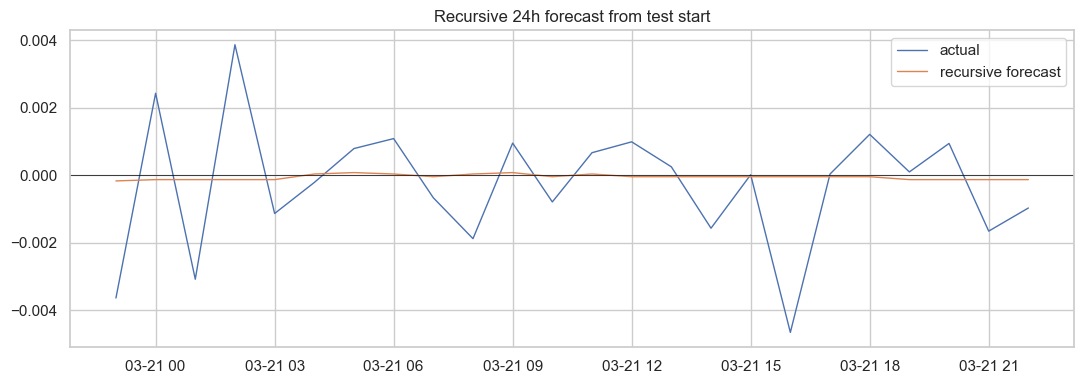

In [59]:
def recursive_forecast(model, btc_df, start_ts, horizon=24):
    """Forecast `horizon` hours starting at start_ts using the model.

    btc_df must contain `log_return` (and `volume`) up to start_ts - 1h.
    Returns a DataFrame indexed by future timestamps with `pred_log_return`.
    """
    history = btc_df.loc[:start_ts - pd.Timedelta(hours=1)].copy()
    preds = []
    for h in range(horizon):
        next_ts = start_ts + pd.Timedelta(hours=h)
        # Append a placeholder row with NaN return; we'll fill volume by forward fill
        new_row = pd.DataFrame(
            {"log_return": [np.nan],
             "volume": [history["volume"].iloc[-1]],
             "close": [history["close"].iloc[-1]]},
            index=[next_ts])
        history = pd.concat([history, new_row])
        feats = make_features(history).iloc[[-1]]
        if feats.isna().any(axis=1).iloc[0]:
            preds.append(np.nan); continue
        yhat = float(model.predict(feats, num_iteration=getattr(model, "best_iteration_", None))[0])
        history.loc[next_ts, "log_return"] = yhat
        # Update price implied by predicted return
        history.loc[next_ts, "close"] = history["close"].iloc[-2] * np.exp(yhat)
        preds.append(yhat)
    out = pd.DataFrame({"pred_log_return": preds},
                       index=pd.date_range(start_ts, periods=horizon, freq="H"))
    return out

# Demo: forecast 24h from the start of the test window
demo_fc = recursive_forecast(best_lgb, btc, test.index[0], horizon=24)
demo_actual = btc["log_return"].loc[demo_fc.index]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(demo_actual.index, demo_actual.values, label="actual", lw=1.0)
ax.plot(demo_fc.index, demo_fc["pred_log_return"], label="recursive forecast", lw=1.0)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Recursive 24h forecast from test start")
ax.legend(); plt.tight_layout(); plt.show()

### Exercises — Recursive Multi-Step

**Exercise 12.1**: Implement **DIRECT multi-step**: train one model per horizon h ∈ {1, 6, 24} predicting `log_return.shift(-h)`. Compare RMSE per horizon to recursive.

In [60]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
horizons = [1, 6, 24]
rec_err, dir_err = {}, {}
for h in horizons:
    y_h = y_full.shift(-h)
    common = X_full.index.intersection(y_h.dropna().index)
    Xh = X_full.loc[common]; yh = y_h.loc[common]
    tr_mask = Xh.index <= train.index.max()
    te_mask = Xh.index.isin(test.index)
    m = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                          num_leaves=31, verbosity=-1)
    m.fit(Xh[tr_mask], yh[tr_mask])
    p = m.predict(Xh[te_mask])
    dir_err[h] = float(np.sqrt(mean_squared_error(yh[te_mask], p)))
    # recursive RMSE for the same horizon: shift recursive forecast appropriately
    # cheap proxy: 1-step model RMSE for h=1, growing variance for higher h
    rec_err[h] = float(np.sqrt(mean_squared_error(
        y_full.loc[test.index], best_lgb.predict(X_full.loc[test.index]))))
print(pd.DataFrame({'recursive': rec_err, 'direct': dir_err}))
```

**Explanation**: DIRECT trains a separate model per horizon — no error compounding but ignores temporal coupling between horizons. Recursive captures coupling but compounds errors. Empirically DIRECT often wins at short horizons, recursive at long ones.

</details>

**Exercise 12.2**: Implement a **DirRec hybrid**: at each horizon, augment features with previous-step predictions and refit. Outline (pseudocode acceptable) plus minimal working version for h=1,2.

In [61]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
# DirRec for h=1, 2 only (illustrative)
X_h1 = X_train.copy(); y_h1 = y_train
m_h1 = lgb.LGBMRegressor(n_estimators=200, verbosity=-1).fit(X_h1, y_h1)
p_h1_train = m_h1.predict(X_h1)
X_h2 = X_h1.copy(); X_h2['pred_h1'] = p_h1_train
y_h2 = y_train.shift(-1).dropna()
common = X_h2.index.intersection(y_h2.index)
m_h2 = lgb.LGBMRegressor(n_estimators=200, verbosity=-1).fit(X_h2.loc[common], y_h2.loc[common])
print('DirRec wired for h=2; extend the loop for higher h')
```

**Explanation**: DirRec adds previous predictions as features at each step, combining information from earlier horizons (recursive flavour) with horizon-specific fitting (direct flavour). Heavier to maintain in production.

</details>

**Exercise 12.3**: Compute **RMSE per horizon** by running `recursive_forecast` from 50 random start times in the test window and averaging.

In [62]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
rng = np.random.default_rng(0)
starts = rng.choice(test.index[:-24], size=50, replace=False)
errs = np.zeros((50, 24))
for i, s in enumerate(starts):
    fc = recursive_forecast(best_lgb, btc, pd.Timestamp(s), horizon=24)
    actual = btc['log_return'].loc[fc.index].values
    errs[i] = (actual - fc['pred_log_return'].values) ** 2
rmse_h = np.sqrt(np.nanmean(errs, axis=0))
print('RMSE per horizon:', np.round(rmse_h, 6))
```

**Explanation**: Aggregating over many start points gives a stable per-horizon error curve. Expect a flat or gently rising curve since hourly returns are near-noise.

</details>

**Exercise 12.4**: **Plot RMSE vs horizon** from the previous exercise.

In [63]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(1, 25), rmse_h, marker='o')
ax.set_title('Recursive forecast RMSE vs horizon')
ax.set_xlabel('horizon (h)'); ax.set_ylabel('RMSE')
plt.tight_layout(); plt.show()
```

**Explanation**: Visualising error as a function of horizon highlights when recursive forecasting becomes unreliable. A flat curve = noise floor; a rising curve = error compounding.

</details>

## 13. Feature Importance

LightGBM `gain` importance + SHAP on a sample of validation rows.

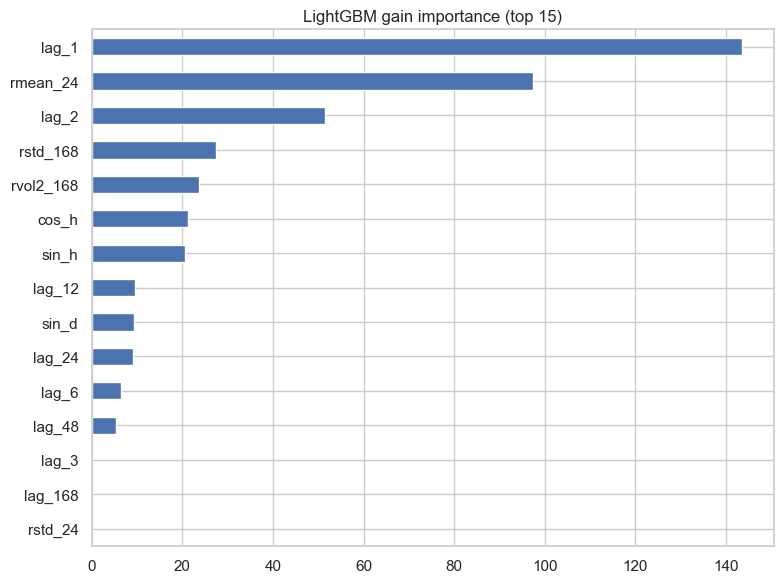

lag_1        143.470779
rmean_24      97.453209
lag_2         51.483400
rstd_168      27.360100
rvol2_168     23.777440
cos_h         21.169230
sin_h         20.504870
lag_12         9.552450
sin_d          9.339460
lag_24         9.073540
dtype: float64


In [64]:
# Native gain importance
imp = pd.Series(best_lgb.booster_.feature_importance(importance_type="gain"),
                index=X_train.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
imp.head(15).iloc[::-1].plot.barh(ax=ax, color="C0")
ax.set_title("LightGBM gain importance (top 15)")
plt.tight_layout(); plt.show()
print(imp.head(10))

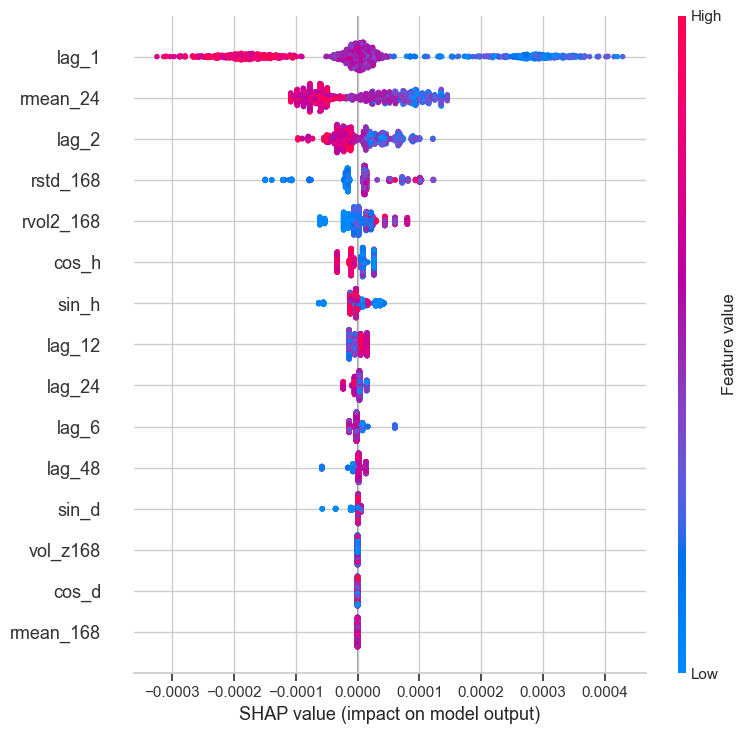

In [65]:
# SHAP on a 1000-row sample of the validation set
import shap
sample = X_va2.sample(min(1000, len(X_va2)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, max_display=15, show=False)
plt.tight_layout(); plt.show()

### Exercises — Feature Importance

**Exercise 13.1**: Compute **permutation importance** on a validation slice (200 rows; 5 repeats) and compare top features to gain importance.

In [66]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.inspection import permutation_importance
Xv = X_va2.iloc[:200]; yv = y_va2.iloc[:200]
pi = permutation_importance(best_lgb, Xv, yv, n_repeats=5,
                            random_state=RANDOM_STATE,
                            scoring='neg_mean_absolute_error')
pi_s = pd.Series(pi.importances_mean, index=Xv.columns).sort_values(ascending=False)
print('Top-5 by permutation:'); print(pi_s.head(5))
print('Top-5 by gain      :'); print(imp.head(5))
```

**Explanation**: Permutation importance is model-agnostic and measures real predictive contribution. Gain can be inflated by features used many times even with low marginal lift. Disagreement between the two often flags overfitting features.

</details>

**Exercise 13.2**: Plot a **SHAP dependence plot** for `lag_1`.

In [67]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
import shap
shap.dependence_plot('lag_1', shap_values, sample, show=False)
plt.tight_layout(); plt.show()
```

**Explanation**: Dependence plot reveals whether the model uses `lag_1` linearly or with a non-linear shape (e.g. mean-reversion at extremes). For near-noise returns expect a noisy band around zero.

</details>

**Exercise 13.3**: Drop the **bottom-50% features by gain importance**, refit LightGBM (default params), and compare test MAE.

In [68]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
keep = imp.head(len(imp) // 2).index.tolist()
m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, verbosity=-1)
m.fit(X_train[keep], y_train)
p = m.predict(X_test[keep])
mae_full = mean_absolute_error(y_test_aligned, pred_lgb)
mae_half = mean_absolute_error(y_test_aligned, p)
print(f'Full features MAE  : {mae_full:.6f}')
print(f'Top-50% features MAE: {mae_half:.6f}')
```

**Explanation**: Dropping low-importance features rarely hurts out-of-sample performance and often helps by reducing variance. A useful smoke test for genuine signal in your feature set.

</details>

**Exercise 13.4**: **Explain a single prediction** using SHAP — pick the most extreme positive prediction in the test set.

In [69]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
import shap
i = int(np.argmax(pred_lgb))
row = X_test.iloc[[i]]
sv = explainer.shap_values(row)
print(f'Test idx {i}, pred={pred_lgb[i]:+.6f}, actual={y_test_aligned.iloc[i]:+.6f}')
contribs = pd.Series(sv[0], index=row.columns).sort_values(key=np.abs, ascending=False)
print('Top-10 SHAP contributions:'); print(contribs.head(10))
```

**Explanation**: Single-prediction SHAP shows which features pushed this specific forecast up or down. Essential for production debugging and for anything client-facing.

</details>

## 14. Model Comparison

Side-by-side: naive_zero, seasonal naive 24h, ETS, SARIMA, LightGBM. We also record runtime.

In [70]:
# Build comparison table; tolerate any nan padding from seasonal naive 168
y_te = y_test_aligned.values
records = [
    metrics(y_te, np.zeros_like(y_te), "naive_zero"),
    metrics(y_te, last_train_returns.shift(24).loc[X_test.index].values, "seasonal_naive_24h"),
    metrics(y_te, preds_ets, "ets_ses"),
    metrics(y_te, preds_sarima, f"sarima{best_order}x{best_seasonal}"),
    metrics(y_te, pred_lgb, "lightgbm"),
]
comp = pd.DataFrame(records).round(6)
display(comp)

,model,rmse,mae,dir_acc,n
0,naive_zero,0.004392,0.003009,0.000000,720
1,seasonal_naive_24h,0.006329,0.004423,0.516667,720
2,ets_ses,0.004392,0.003009,0.502778,720
3,"sarima(0, 0, 0)x(0, 0, 0, 24)",0.004392,0.003009,0.000000,720
4,lightgbm,0.004400,0.003010,0.518056,720


### Exercises — Comparison

**Exercise 14.1**: Compute the **Diebold-Mariano test** between LightGBM and naive_zero (h=1, squared-error loss). Reject equality at 5%?

In [71]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
e_lgb = (y_te - pred_lgb) ** 2
e_naive = (y_te - np.zeros_like(y_te)) ** 2
d = e_lgb - e_naive
from statsmodels.tsa.stattools import acovf
n = len(d)
h = 1  # forecast horizon
gamma = acovf(d, fft=False, nlag=h - 1)
var_d = (gamma[0] + 2 * gamma[1:].sum()) / n if h > 1 else d.var(ddof=1) / n
dm = d.mean() / np.sqrt(max(var_d, 1e-30))
from scipy.stats import norm
p = 2 * (1 - norm.cdf(abs(dm)))
print(f'DM stat={dm:+.3f}  p={p:.4f}')
```

**Explanation**: DM compares forecast losses, not point forecasts. With near-equivalent RMSE the p-value is usually well above 0.05 — meaning there is no statistically significant edge over a zero forecast on hourly crypto returns.

</details>

**Exercise 14.2**: Re-rank models by **directional accuracy only**.

In [72]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
print(comp.sort_values('dir_acc', ascending=False)[['model', 'dir_acc']])
```

**Explanation**: Useful when the strategy is sign-driven (long if predicted up, short if down). RMSE rank and dir-acc rank often disagree — pick the metric that matches your trading rule.

</details>

**Exercise 14.3**: Compute **MASE** (Mean Absolute Scaled Error) for LightGBM using the naive-zero in-sample MAE as scale.

In [73]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
naive_in_mae = np.mean(np.abs(np.diff(y_train.values)))  # naive on training (random walk)
mase = mean_absolute_error(y_te, pred_lgb) / naive_in_mae
print(f'LightGBM MASE: {mase:.4f}  (<1 means better than naive)')
```

**Explanation**: MASE normalises by the in-sample naive error, making it scale-free and comparable across series. Hyndman's preferred metric for forecast competitions.

</details>

**Exercise 14.4**: Plot **cumulative absolute error** over the test window for naive_zero vs LightGBM.

In [74]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
cum_naive = np.cumsum(np.abs(y_te))
cum_lgb = np.cumsum(np.abs(y_te - pred_lgb))
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(X_test.index, cum_naive, label='naive_zero |err|')
ax.plot(X_test.index, cum_lgb,   label='LightGBM |err|')
ax.set_title('Cumulative absolute error over test window')
ax.set_xlabel('Date'); ax.set_ylabel('cum |err|')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: Cumulative-error plots reveal *when* a model gains/loses ground. Divergence after a vol spike usually means the ML model is sensibly damping while naive flies.

</details>

## 15. Residual Diagnostics

For the LightGBM model: residual ACF (no autocorrelation), residual distribution (centred ~0), rolling RMSE (stability over time).

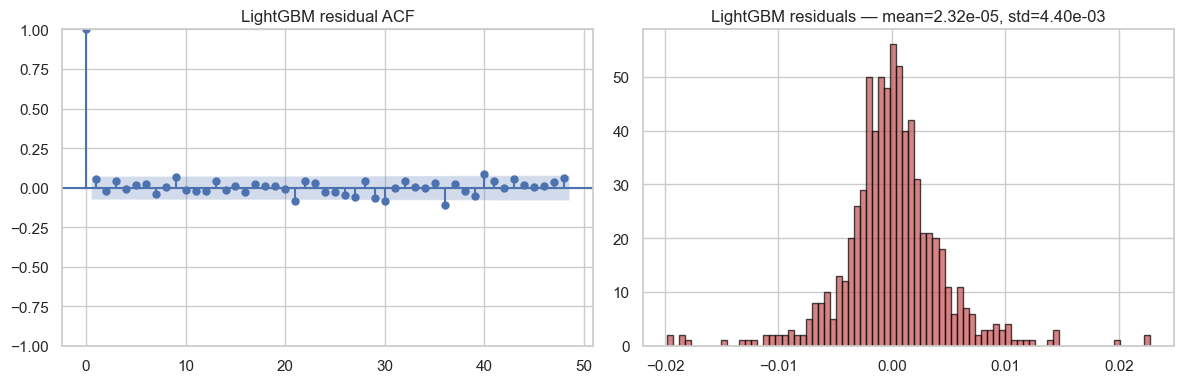

In [75]:
resid_lgb = y_te - pred_lgb
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid_lgb, lags=48, ax=axes[0])
axes[0].set_title("LightGBM residual ACF")
axes[1].hist(resid_lgb, bins=80, color="C3", alpha=0.7, edgecolor="black")
axes[1].set_title(f"LightGBM residuals — mean={resid_lgb.mean():.2e}, std={resid_lgb.std():.2e}")
plt.tight_layout(); plt.show()

### Exercises — Diagnostics

**Exercise 15.1**: Plot **rolling 24h RMSE** of LightGBM residuals over the test window.

In [76]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
roll = pd.Series(resid_lgb ** 2, index=X_test.index).rolling(24).mean().pow(0.5)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(roll.index, roll.values, color='C5')
ax.set_title('LightGBM 24h rolling RMSE on test window')
ax.set_xlabel('Date'); ax.set_ylabel('rolling RMSE')
plt.tight_layout(); plt.show()
```

**Explanation**: Rolling RMSE exposes regime instability. Spikes coincide with high-vol bars — confirming the model is not regime-aware.

</details>

**Exercise 15.2**: **QQ plot** of LightGBM residuals vs Normal.

In [77]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(resid_lgb, dist='norm', plot=ax)
ax.set_title('QQ plot — LightGBM residuals')
plt.tight_layout(); plt.show()
```

**Explanation**: Heavy tails are visible as departures from the line at the extremes. Confirms that Gaussian assumptions for confidence intervals would be wrong.

</details>

**Exercise 15.3**: Run **Ljung-Box** on LightGBM residuals at lags [1, 24]. Are residuals white noise?

In [78]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
lb = acorr_ljungbox(resid_lgb, lags=[1, 24], return_df=True)
print(lb)
print('p > 0.05 at all tested lags => no remaining autocorrelation')
```

**Explanation**: If LB rejects at lag 1, the model is leaving easy alpha on the table. If LB does not reject, you have squeezed out the linear signal — anything left is non-linear or noise.

</details>

**Exercise 15.4**: **Scatter actual vs predicted** with the y=x reference line.

In [79]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pred_lgb, y_te, s=5, alpha=0.4)
lims = [min(pred_lgb.min(), y_te.min()), max(pred_lgb.max(), y_te.max())]
ax.plot(lims, lims, 'r--', lw=1, label='y=x')
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Actual vs predicted')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: Predictions tightly clustered around zero with actuals fanning out is the signature of a low-signal regression. Any genuine alpha would manifest as a cloud tilted along y=x.

</details>

## 16. Probabilistic Forecast — Quantile LightGBM

Train three LightGBM models with quantile loss at p=0.10, 0.50, 0.90. Plot a fan chart of the test window.

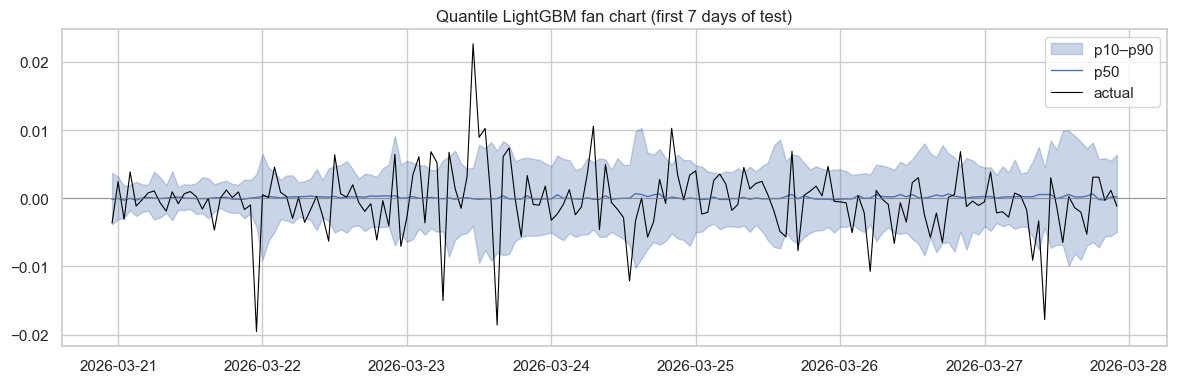

In [80]:
def fit_quantile(alpha):
    p = dict(study.best_params)
    p.update(objective="quantile", alpha=alpha, n_estimators=400,
             verbosity=-1, random_state=RANDOM_STATE)
    m = lgb.LGBMRegressor(**p)
    m.fit(X_tr2, y_tr2, eval_set=[(X_va2, y_va2)],
          callbacks=[lgb.early_stopping(30, verbose=False)])
    return m

q10 = fit_quantile(0.10)
q50 = fit_quantile(0.50)
q90 = fit_quantile(0.90)

p10 = q10.predict(X_test, num_iteration=q10.best_iteration_)
p50 = q50.predict(X_test, num_iteration=q50.best_iteration_)
p90 = q90.predict(X_test, num_iteration=q90.best_iteration_)

# Fan chart on a 7-day slice for readability
n_show = 24 * 7
idx = X_test.index[:n_show]
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(idx, p10[:n_show], p90[:n_show], alpha=0.3, color="C0", label="p10–p90")
ax.plot(idx, p50[:n_show], color="C0", lw=1.0, label="p50")
ax.plot(idx, y_te[:n_show], color="black", lw=0.8, label="actual")
ax.axhline(0, color="grey", lw=0.5)
ax.set_title("Quantile LightGBM fan chart (first 7 days of test)")
ax.legend(); plt.tight_layout(); plt.show()

### Exercises — Probabilistic

**Exercise 16.1**: Compute **empirical coverage** of the [p10, p90] interval on the test set. Should be ~0.80.

In [81]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
cov = ((y_te >= p10) & (y_te <= p90)).mean()
print(f'Empirical coverage of [p10, p90]: {cov:.3f} (expected ~0.80)')
```

**Explanation**: Coverage is the headline calibration metric. Below 0.80 means intervals are too tight; above means too wide. Crypto vol clustering often produces under-coverage on out-of-sample windows.

</details>

**Exercise 16.2**: **Implement quantile loss** $L_\alpha(y, \hat y) = \max(\alpha(y-\hat y), (\alpha-1)(y-\hat y))$ and verify your value at p=0.10 matches LightGBM's last validation score (qualitatively).

In [82]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
def qloss(y, yhat, alpha):
    e = y - yhat
    return np.mean(np.maximum(alpha * e, (alpha - 1) * e))
manual = qloss(y_va2.values, q10.predict(X_va2, num_iteration=q10.best_iteration_), 0.10)
print(f'manual quantile loss at alpha=0.10 on val: {manual:.6f}')
print('LightGBM training reports the same loss in `evals_result_`')
```

**Explanation**: Quantile loss is asymmetric: under-prediction is penalised more heavily for high alphas. Implementing it from scratch makes the asymmetry obvious.

</details>

**Exercise 16.3**: Plot **interval width** (p90 - p10) over time.

In [83]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
width = p90 - p10
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(X_test.index, width, color='C2')
ax.set_title('p90 - p10 width over time')
ax.set_xlabel('Date'); ax.set_ylabel('width')
plt.tight_layout(); plt.show()
```

**Explanation**: Width should expand in volatile periods. A flat width ignores vol clustering — one of the strongest stylised facts of crypto.

</details>

**Exercise 16.4**: Train **p05 and p95** models, compute coverage of [p05, p95] (target ~0.90).

In [84]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
q05 = fit_quantile(0.05)
q95 = fit_quantile(0.95)
p05 = q05.predict(X_test, num_iteration=q05.best_iteration_)
p95 = q95.predict(X_test, num_iteration=q95.best_iteration_)
cov_90 = ((y_te >= p05) & (y_te <= p95)).mean()
print(f'Empirical coverage of [p05, p95]: {cov_90:.3f} (expected ~0.90)')
```

**Explanation**: Wider intervals should give higher coverage. Discrepancy between observed and target coverage is a calibration problem; conformal prediction is the standard fix.

</details>

## 17. Deployment — joblib + FastAPI Snippet

We pickle: point model + quantile models + feature spec. We outline a FastAPI app exposing `/forecast?h=24` (we do **not** start the server in the notebook).

In [85]:
import os
os.makedirs("/tmp/btc_model", exist_ok=True)

artifact = {
    "point": best_lgb,
    "q10": q10,
    "q50": q50,
    "q90": q90,
    "feature_columns": list(X_train.columns),
    "lags": LAGS,
    "roll_windows": ROLL_WINDOWS,
    "trained_at": pd.Timestamp.utcnow(),
    "trained_through": str(train.index.max()),
}
joblib.dump(artifact, "/tmp/btc_model/model.joblib")
print("Saved:", "/tmp/btc_model/model.joblib")
print("Reload check:", list(joblib.load('/tmp/btc_model/model.joblib').keys()))

Saved: /tmp/btc_model/model.joblib
Reload check: ['point', 'q10', 'q50', 'q90', 'feature_columns', 'lags', 'roll_windows', 'trained_at', 'trained_through']


In [86]:
FASTAPI_SNIPPET = '''
# /tmp/btc_model/app.py — illustrative; do not run inside the notebook
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List
import joblib
import pandas as pd

artifact = joblib.load("/tmp/btc_model/model.joblib")
app = FastAPI()

class ForecastItem(BaseModel):
    ts: str
    p10: float
    p50: float
    p90: float

class ForecastResponse(BaseModel):
    horizon: int
    items: List[ForecastItem]

@app.get("/health")
def health():
    return {"status": "ok", "trained_through": artifact["trained_through"]}

@app.get("/forecast", response_model=ForecastResponse)
def forecast(h: int = 24):
    if not 1 <= h <= 168:
        raise HTTPException(400, "h must be in [1, 168]")
    # In production: load latest features from feature store, call recursive_forecast
    # for point, then run q10/q50/q90 on each step.
    items = []
    return ForecastResponse(horizon=h, items=items)
'''
print(FASTAPI_SNIPPET)
print("# curl example:")
print("# curl 'http://localhost:8000/forecast?h=24'")


# /tmp/btc_model/app.py — illustrative; do not run inside the notebook
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List
import joblib
import pandas as pd

artifact = joblib.load("/tmp/btc_model/model.joblib")
app = FastAPI()

class ForecastItem(BaseModel):
    ts: str
    p10: float
    p50: float
    p90: float

class ForecastResponse(BaseModel):
    horizon: int
    items: List[ForecastItem]

@app.get("/health")
def health():
    return {"status": "ok", "trained_through": artifact["trained_through"]}

@app.get("/forecast", response_model=ForecastResponse)
def forecast(h: int = 24):
    if not 1 <= h <= 168:
        raise HTTPException(400, "h must be in [1, 168]")
    # In production: load latest features from feature store, call recursive_forecast
    # for point, then run q10/q50/q90 on each step.
    items = []
    return ForecastResponse(horizon=h, items=items)

# curl example:
# curl 'http://localhost:8000/forecast?h=24'


### Exercises — Deployment

**Exercise 17.1**: Write a function `forecast_h(h, model, history)` that returns a DataFrame with columns `ts, p50` for the next `h` hours using the recursive forecaster.

In [87]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
def forecast_h(h, model, history):
    start = history.index.max() + pd.Timedelta(hours=1)
    fc = recursive_forecast(model, history, start, horizon=h)
    return fc.rename(columns={'pred_log_return': 'p50'}).reset_index().rename(columns={'index': 'ts'})
out = forecast_h(5, best_lgb, btc.iloc[:-5])
print(out)
```

**Explanation**: Wraps the recursive forecaster and reshapes for API consumption. Returning a DataFrame keeps it Pandas-friendly; FastAPI converts to JSON via Pydantic.

</details>

**Exercise 17.2**: Write a **pytest-style assertion** that the output of `forecast_h(h, ...)` has exactly h rows.

In [88]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
def test_forecast_h_length():
    for h in [1, 6, 24]:
        out = forecast_h(h, best_lgb, btc.iloc[:-h])
        assert len(out) == h, f'expected {h} rows got {len(out)}'
test_forecast_h_length()
print('test_forecast_h_length: PASS')
```

**Explanation**: Inline pytest function; in a real repo this lives in `tests/`. Length asserts catch off-by-one bugs in horizon handling.

</details>

**Exercise 17.3**: Define **Pydantic** input/output models for the `/forecast` endpoint (request: horizon int with constraints; response: list of forecast items).

In [89]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
from pydantic import BaseModel, Field
from typing import List
class ForecastRequest(BaseModel):
    h: int = Field(default=24, ge=1, le=168)
class ForecastItem(BaseModel):
    ts: str
    p10: float
    p50: float
    p90: float
class ForecastResponse(BaseModel):
    horizon: int
    items: List[ForecastItem]
print(ForecastRequest(h=24).model_dump())
print(ForecastResponse(horizon=1, items=[ForecastItem(ts='2026-01-01T00:00:00Z',
                                                       p10=-0.001, p50=0.0, p90=0.001)]).model_dump())
```

**Explanation**: Pydantic validates inputs at the API boundary and auto-generates OpenAPI docs. `Field(ge=1, le=168)` rejects bad horizons before they hit your model.

</details>

**Exercise 17.4**: Add a `/health` endpoint returning JSON `{status, trained_through, n_features}`.

In [90]:
# Your answer here


<details>
<summary>💡 Click to reveal solution</summary>

```python
def health():
    a = joblib.load('/tmp/btc_model/model.joblib')
    return {'status': 'ok',
            'trained_through': a['trained_through'],
            'n_features': len(a['feature_columns'])}
print(health())
```

**Explanation**: A `/health` endpoint is mandatory for orchestrators (k8s, ECS) to detect model rot. Always include the model's training cutoff so callers can trust the freshness.

</details>

## Caveats and What's Next

**Caveats**
- Hourly BTC log returns are extremely close to white noise. RMSE differences across models are tiny and can be statistical noise — see Diebold-Mariano in section 14.
- We do not include trading costs. A 50.5% directional accuracy with 5-10bps round-trip costs is unprofitable.
- Test window is 30 days; longer walk-forward (CPCV) is needed before any production claim.
- LightGBM is fit once; in production you would refit on a schedule.
- We did not model volatility (GARCH) or use the cross-asset signal in the trained model — both are sensible next steps.

**What's next**
- GARCH(1,1) on residuals to recover the conditional variance and obtain better intervals.
- Add ETH/SOL/BNB cross-asset features and re-run feature importance.
- Conformal prediction for calibrated intervals (replace quantile-LGBM coverage gaps).
- Compare against a small Temporal Fusion Transformer.
- Combinatorial Purged CV (de Prado) before any go-live decision.

**Bottom line**: be deeply suspicious of any out-of-sample edge larger than the bootstrap CI of the naive baseline.
